### Zillow Home Price Prediction using 5 ML Algorithms in Sklearn

##### 1. Importing Dataset

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Loading the Dataset

In [85]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/19-Home%20Price%20Prediction/Zillow.csv

--2026-03-10 11:21:34--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/19-Home%20Price%20Prediction/Zillow.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20494487 (20M) [text/plain]
Saving to: ‘Zillow.csv.2’

Zillow.csv.2        100%[===================>]  19.54M  20.0MB/s    in 1.0s    

2026-03-10 11:21:35 (20.0 MB/s) - ‘Zillow.csv.2’ saved [20494487/20494487]



In [86]:
df = pd.read_csv('Zillow.csv')
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,target
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,485713.0,1023282.0,2016.0,537569.0,11013.72,NaN,NaN,6.059063e+13,0.025595
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,88000.0,464000.0,2016.0,376000.0,5672.48,NaN,NaN,6.111001e+13,0.055619
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,85289.0,564778.0,2016.0,479489.0,6488.30,NaN,NaN,6.059022e+13,0.005383
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,108918.0,145143.0,2016.0,36225.0,1777.51,NaN,NaN,6.037300e+13,-0.103410
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,73681.0,119407.0,2016.0,45726.0,1533.89,NaN,NaN,6.037124e+13,0.006940


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 59 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

##### 3. Data Cleaning

In [88]:
to_remove = []
for col in df.columns:
# Removing columns having only one value.
    if df[col].nunique() ==1:
        to_remove.append(col)
# Removing columns with more than 90% of the rows as null values.
    elif (df[col].isnull()).mean() > 0.60:
        to_remove.append(col)

print(len(to_remove))

df.drop(to_remove, axis=1, inplace = True)

30


In [89]:
len(df.columns)

29

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   bathroomcnt                   77579 non-null  float64
 2   bedroomcnt                    77579 non-null  float64
 3   buildingqualitytypeid         49809 non-null  float64
 4   calculatedbathnbr             76963 non-null  float64
 5   calculatedfinishedsquarefeet  77378 non-null  float64
 6   finishedsquarefeet12          73923 non-null  float64
 7   fips                          77579 non-null  float64
 8   fullbathcnt                   76963 non-null  float64
 9   heatingorsystemtypeid         49571 non-null  float64
 10  latitude                      77579 non-null  float64
 11  longitude                     77579 non-null  float64
 12  lotsizesquarefeet             69321 non-null  float64
 13  p

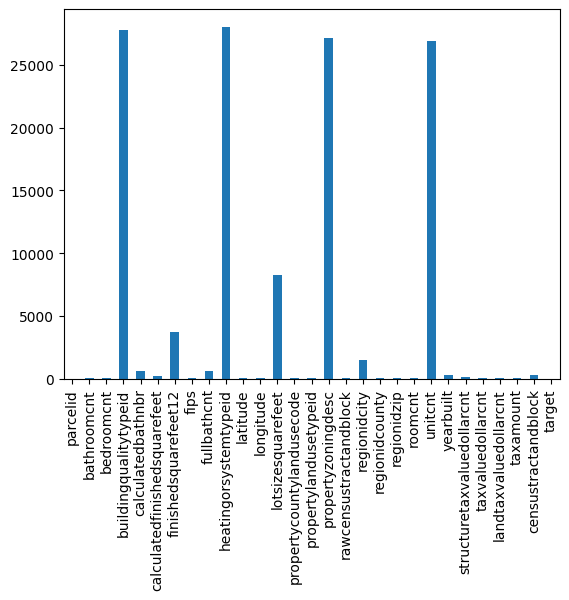

In [91]:
df.isnull().sum().plot.bar()
plt.show()

In [92]:
df.isnull().sum().sum()

np.int64(126184)

In [93]:
df['propertycountylandusecode'].mode()[0]

'0100'

In [94]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif df[col].dtype == np.number:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

/tmp/ipykernel_1096/644562647.py:4: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  elif df[col].dtype == np.number:


np.int64(0)

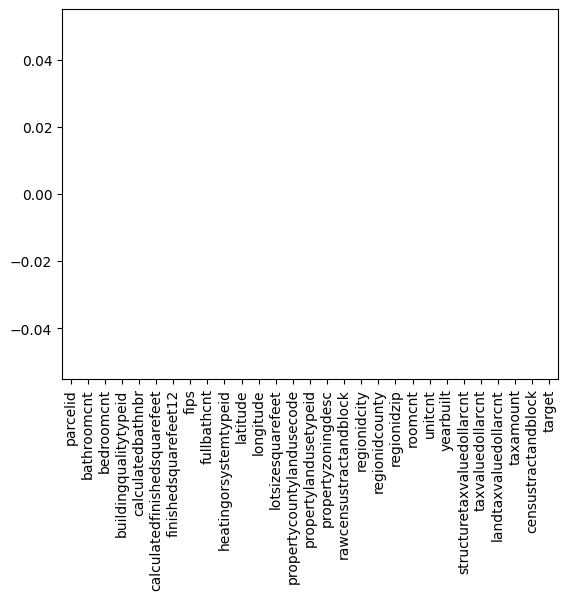

In [95]:
df.isnull().sum().plot.bar()
plt.show()

##### 4. EDA

In [96]:
ints, floats, objects = [], [], []
for col in df.columns:
    if df[col].dtype == object:
        objects.append(col)
    elif df[col].dtype == int:
        ints.append(col)
    elif df[col].dtype == float:
        floats.append(col)

len(ints), len(floats), len(objects)

(1, 26, 2)

In [97]:
for col in objects:
    print(col, '->', df[col].nunique())
    print(df[col].unique())
    print()

propertycountylandusecode -> 75
['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222' '1310'
 '1120' '0111' '1116' '1421' '0110' '0105' '012E' '0141' '1333' '0115'
 '040V' '010L' '040B' '012D' '0114' '0203' '030G' '0130' '105' '020G'
 '020M' '020E']

propertyzoningdesc -> 1907
['LAR1' 'LCR110000*' 'LAR3' ... 'HAR4-R2*' 'LCR1VV' 'BFA15000*']



<Figure size 800x500 with 0 Axes>

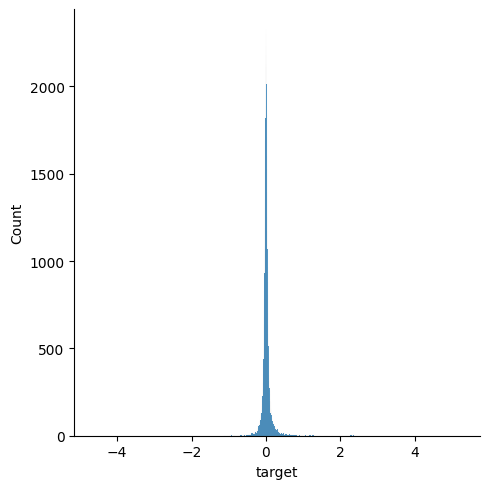

In [98]:
plt.figure(figsize=(8, 5))
sns.displot(df['target'])
plt.show()

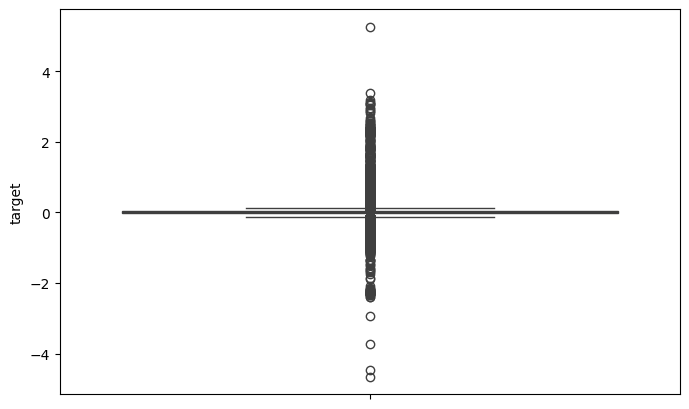

In [99]:
plt.figure(figsize=(8, 5))
sns.boxplot(df['target'])
plt.show()

In [100]:
print('Shape of the dataframe before removal of outliers', df.shape)
df = df[(df['target'] > -1) & (df['target'] < 1)]
print('Shape of the dataframe after removal of outliers ', df.shape)

Shape of the dataframe before removal of outliers (77613, 29)
Shape of the dataframe after removal of outliers  (77261, 29)


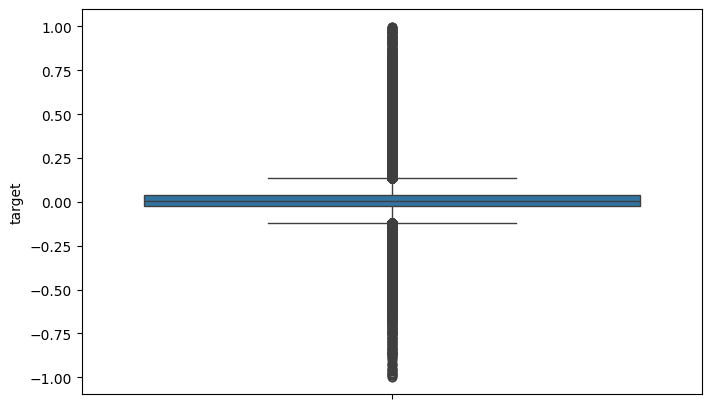

In [101]:
plt.figure(figsize=(8, 5))
sns.boxplot(df['target'])
plt.show()

<Figure size 800x500 with 0 Axes>

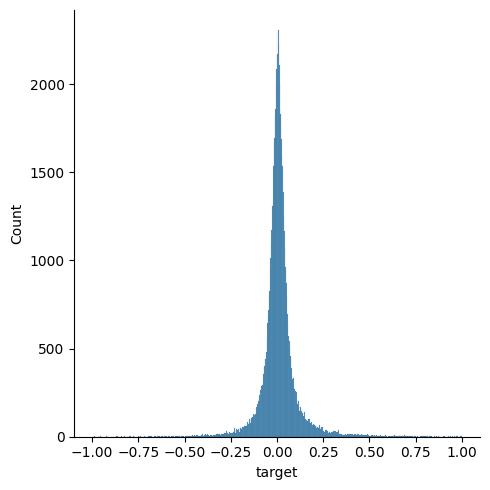

In [102]:
plt.figure(figsize=(8, 5))
sns.displot(df['target'])
plt.show()

##### 5. Data Preprocessing

In [103]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [104]:
X

,parcelid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,...,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,structuretaxvaluedollarcnt,taxvaluedollarcnt,landtaxvaluedollarcnt,taxamount,censustractandblock
0,14297519,3.5,4.0,6.533779,3.5,3100.0,3100.0,6059.0,3.0,3.921749,...,1286.0,96978.0,0.0,1.110309,1998.0,485713.0,1023282.0,537569.0,11013.72,6.059063e+13
1,17052889,1.0,2.0,6.533779,1.0,1465.0,1465.0,6111.0,1.0,3.921749,...,2061.0,97099.0,5.0,1.110309,1967.0,88000.0,464000.0,376000.0,5672.48,6.111001e+13
2,14186244,2.0,3.0,6.533779,2.0,1243.0,1243.0,6059.0,2.0,3.921749,...,1286.0,97078.0,6.0,1.110309,1962.0,85289.0,564778.0,479489.0,6488.30,6.059022e+13
3,12177905,3.0,4.0,8.000000,3.0,2376.0,2376.0,6037.0,3.0,2.000000,...,3101.0,96330.0,0.0,1.000000,1970.0,108918.0,145143.0,36225.0,1777.51,6.037300e+13
4,10887214,3.0,3.0,8.000000,3.0,1312.0,1312.0,6037.0,3.0,2.000000,...,3101.0,96451.0,0.0,1.000000,1964.0,73681.0,119407.0,45726.0,1533.89,6.037124e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,10833991,3.0,3.0,8.000000,3.0,1741.0,1741.0,6037.0,3.0,2.000000,...,3101.0,96415.0,0.0,1.000000,1980.0,265000.0,379000.0,114000.0,4685.34,6.037132e+13
77609,11000655,2.0,2.0,6.000000,2.0,1286.0,1286.0,6037.0,2.0,2.000000,...,3101.0,96284.0,0.0,1.000000,1940.0,70917.0,354621.0,283704.0,4478.43,6.037101e+13
77610,17239384,2.0,4.0,6.533779,2.0,1612.0,1612.0,6111.0,2.0,3.921749,...,2061.0,97116.0,7.0,1.110309,1964.0,50683.0,67205.0,16522.0,1107.48,6.111008e+13
77611,12773139,1.0,3.0,4.000000,1.0,1032.0,1032.0,6037.0,1.0,2.000000,...,3101.0,96480.0,0.0,1.000000,1954.0,32797.0,49546.0,16749.0,876.43,6.037434e+13


In [105]:
y

,target
0,0.025595
1,0.055619
2,0.005383
3,-0.103410
4,0.006940
...,...
77608,-0.002245
77609,0.020615
77610,0.013209
77611,0.037129


In [106]:
from sklearn.preprocessing import LabelEncoder
for col in X.columns:
    if X[col].dtype == object:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

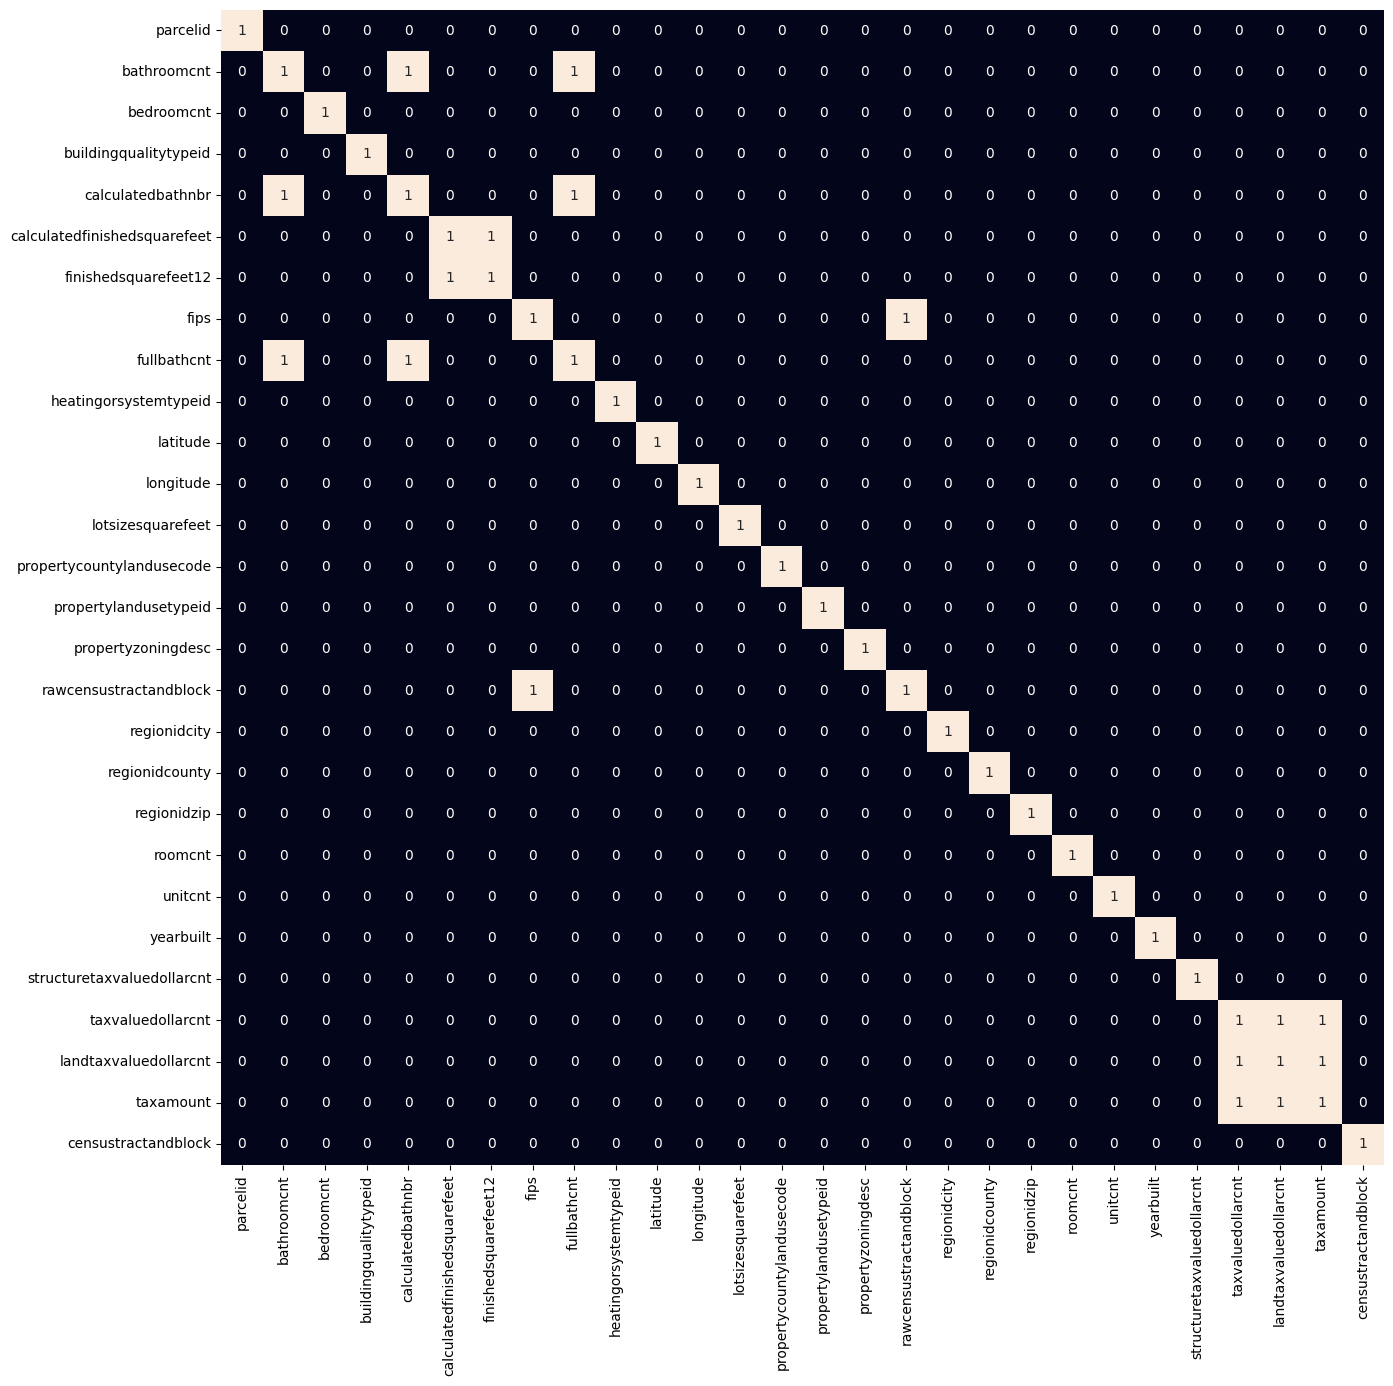

In [107]:
plt.figure(figsize=(15, 15))
sns.heatmap(X.corr()> 0.8, annot=True, cbar=False)
plt.show()

In [108]:
to_remove = ['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt', 'bathroomcnt']

X.drop(to_remove, axis=1, inplace=True)

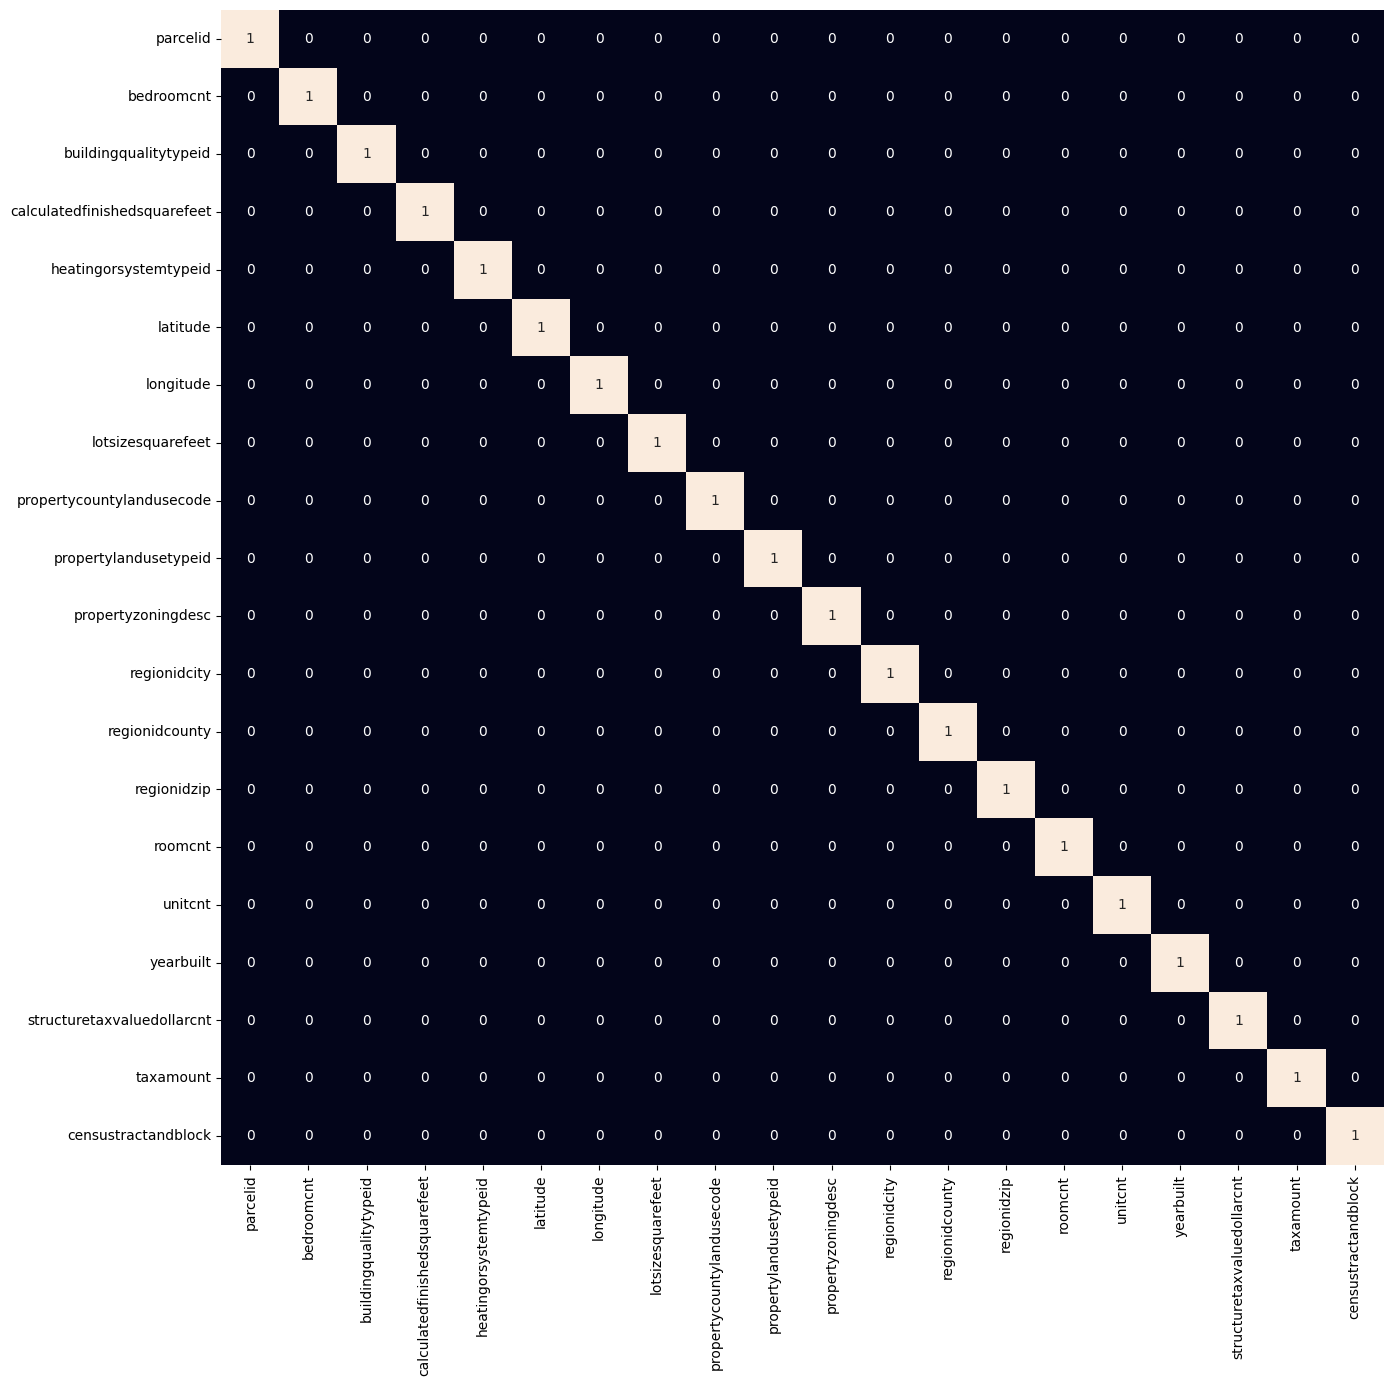

In [109]:
plt.figure(figsize=(15, 15))
sns.heatmap(X.corr()> 0.8, annot=True, cbar=False)
plt.show()

In [110]:
X = X.drop('parcelid', axis=1).values

In [111]:
y = y.values

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [113]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [114]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((69534, 19), (7727, 19), (69534,), (7727,))

##### 6. Modeling and Evaluating

In [115]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

models = [LinearRegression(),
          Lasso(), Ridge(),
          RandomForestRegressor(),
          XGBRegressor()]

model_names = []
train_errors = []
test_errors = []

for model in models:
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    y_preds = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, y_preds)

    model_names.append(type(model).__name__)
    train_errors.append(train_mae)
    test_errors.append(test_mae)

    print(f"{model} :")
    print('Training Error : ', train_mae)
    print('Test Error : ', test_mae)
    print()


LinearRegression() :
Training Error :  0.06229581420094027
Test Error :  0.06187374980382603

Lasso() :
Training Error :  0.06230842082156369
Test Error :  0.06179834066944813

Ridge() :
Training Error :  0.0622958082896114
Test Error :  0.06187374409700509

RandomForestRegressor() :
Training Error :  0.024978628053108638
Test Error :  0.06567512806843587

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_cons

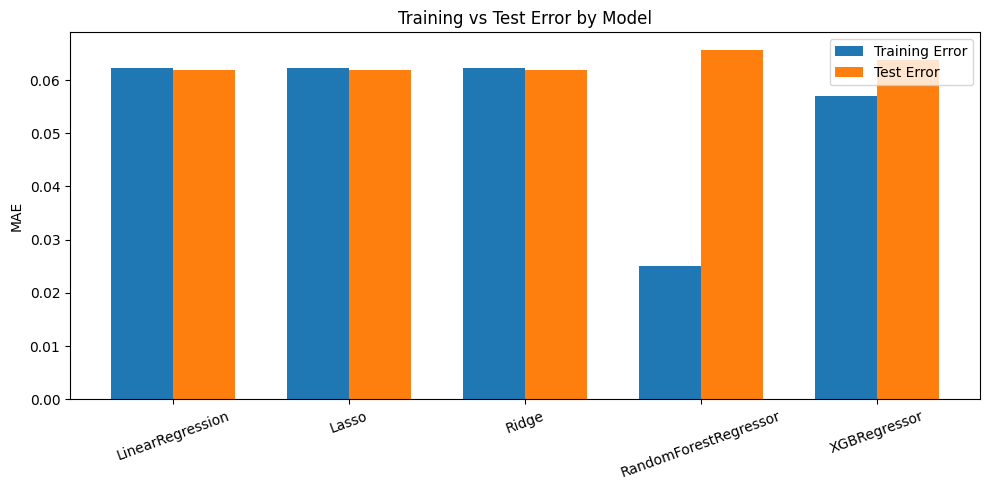

In [116]:
# Plot training and test errors
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_errors, width, label='Training Error')
plt.bar(x + width/2, test_errors, width, label='Test Error')
plt.xticks(x, model_names, rotation=20)
plt.ylabel('MAE')
plt.title('Training vs Test Error by Model')
plt.legend()
plt.tight_layout()
plt.show()

##### 7. Make Prediction

In [119]:
prediction = models[0].predict(X_test)
prediction[0], y_test[0]

(np.float64(0.02007646723421286), np.float64(-0.00185279443971))